In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import GridSearchCV

#   Boosting 

- Make the worst possible model and learn the errors
- This is a sequential model




TypeError: Argument 'placement' has incorrect type (expected pandas._libs.internals.BlockPlacement, got numpy.ndarray)

In [5]:
!pip install "pandas==1.5.3"


  Using cached pandas-1.5.3.tar.gz (5.2 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: still running...
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build pandas


  error: subprocess-exited-with-error
  
  × Building wheel for pandas (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [2527 lines of output]
      <string>:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
      C:\Users\user\AppData\Local\Temp\pip-build-env-h4_jzj50\overlay\Lib\site-packages\setuptools\dist.py:759: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consider removing the following classifiers in favor of a SPDX license expression:
      
              License :: OSI Approved :: BSD License
      
              See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
          

In [6]:
import pickle
# Load data (deserialize)
with open('preprocessed_X_sm.pickle', 'rb') as handle:
    X_train = pickle.load(handle)
    print(type(X_train))


with open('X_test.pickle', 'rb') as handle:
    X_test = pickle.load(handle)

with open('y_sm.pickle', 'rb') as handle:
    y_train = pickle.load(handle)

with open('y_test.pickle', 'rb') as handle:
    y_test = pickle.load(handle)

TypeError: Argument 'placement' has incorrect type (expected pandas._libs.internals.BlockPlacement, got numpy.ndarray)

In [1]:
X_train

NameError: name 'X_train' is not defined

In [1]:
import pandas as pd
import pickle
import numpy as np

with open('preprocessed_X_sm.pickle', 'rb') as handle:
    # X_train = pickle.load(handle)
    X_train = pd.read_pickle("preprocessed_X_sm.pickle")

with open('X_test.pickle', 'rb') as handle:
    # X_test = pickle.load(handle)
    X_test = pd.read_pickle("X_test.pickle")


with open('y_sm.pickle', 'rb') as handle:
    # y_train = pickle.load(handle)
    y_train = pd.read_pickle("y_sm.pickle")


with open('y_test.pickle', 'rb') as handle:
    # y_test = pickle.load(handle)
    y_test = pd.read_pickle("y_test.pickle")

In [2]:
from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier(n_estimators=150, max_depth=2, loss = 'log_loss')
gbc.fit(X_train, y_train)

print("Test Score: ", gbc.score(X_test, y_test))
print("Train Score: ", gbc.score(X_train, y_train))

Test Score:  0.8804347826086957
Train Score:  0.948051948051948


- If we increase max_depth, the model will overfit

- Final model equation: Fm(x) = h0(x) + a1.h1(x) + ... + am.hm(x)
- ai is the weight of the model
- ai is the learning rate
- we can regularize the model by adding a learning rate
- Fm(x) = h0(x) + v(a1.h1(x) + ... + am.hm(x))
- v is the shrinkage
- v is between 0 and 1

# Stochastic Gradient Boosting

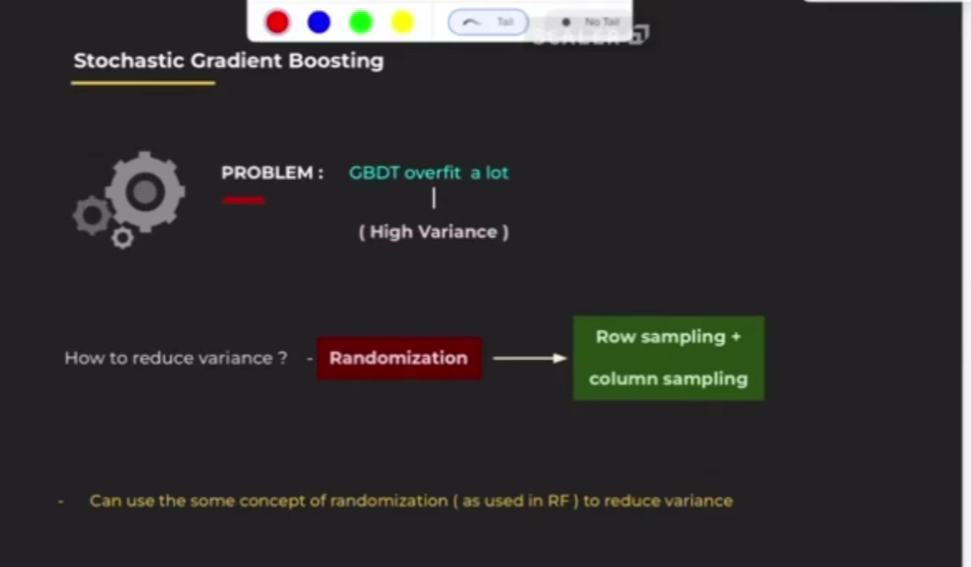

- This is the same as gradient boosting but we use a random sample of the data to train the model
- This variation is called stochastic gradient boosting

In [3]:
!tree "./EMG Physical Action Data Set/sub1"

Folder PATH listing
Volume serial number is F40E-7A1A
C:\USERS\USER\DESKTOP\SPRING TEST\SCAL\LECTURE NOTES\AI_ML MODULE\EMG PHYSICAL ACTION DATA SET\SUB1
+---Aggressive
�   +---log
�   +---txt
+---Normal
    +---log
    +---txt


In [1]:
import pickle


with open('X_train.pickle', 'rb') as handle:
    X_train = pickle.load(handle)

with open('X_test.pickle', 'rb') as handle:
    X_test = pickle.load(handle)

with open('Y_train.pickle', 'rb') as handle:
    y_train = pickle.load(handle)

with open('Y_test.pickle', 'rb') as handle:
    y_test = pickle.load(handle)

- Data is collected for every 0.1 milli second here
- Since, there will be a huge data, we will take one data point randomly for eevry n(for eg. 10) data points


- We will take moving average of the data

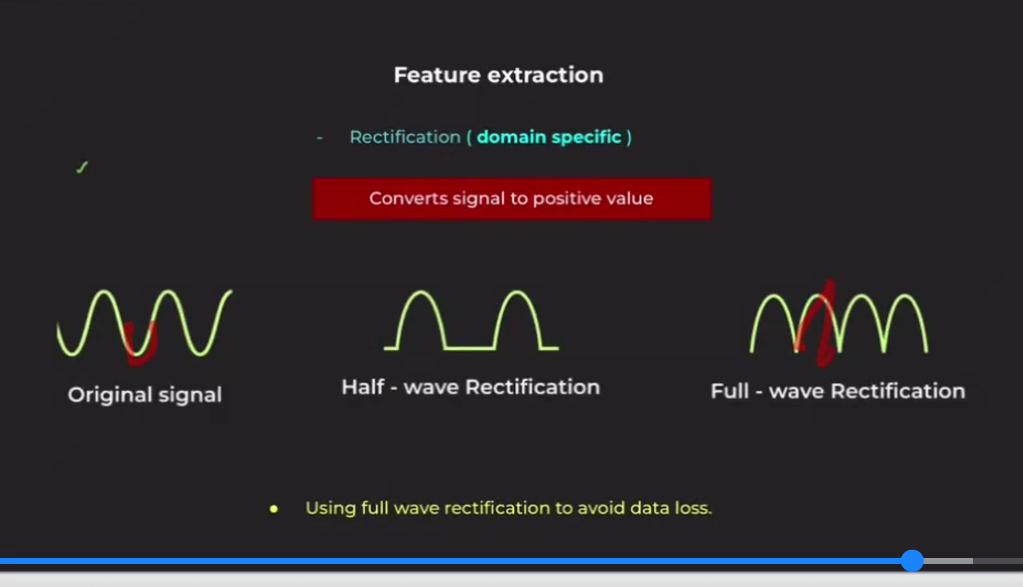


- In the above example of EMV waves, we don't need the negative or positive, we only care about amplitude of the waves

- Use full wave rectification to avoid data loss

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

# need 5 trees
reg = RandomForestRegressor(n_estimators=5)
params = {
          'n_estimators' : [100,200,300,400],
          'max_depth' : [3,5,10],
          'criterion' : ['gini', 'entropy'],
          'bootstrap' : [True, False],
          'max_features' : [8,9,10]
         }

In [3]:
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn import tree
from sklearn.model_selection import GridSearchCV

params = {
    "max_depth" : [3, 5, 7, 10, 15],
    "max_leaf_nodes" : [20, 40, 60]
}

model1 = DTC()
clf = GridSearchCV(model1, params, scoring = "accuracy", cv=5)

clf.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'max_depth': [3, 5, ...], 'max_leaf_nodes': [20, 40, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [4]:
res = clf.cv_results_

for i in range(len(res["params"])):
  print(f"Parameters:{res['params'][i]} Mean_score: {res['mean_test_score'][i]} Rank: {res['rank_test_score'][i]}")


Parameters:{'max_depth': 3, 'max_leaf_nodes': 20} Mean_score: 0.34208509132931136 Rank: 13
Parameters:{'max_depth': 3, 'max_leaf_nodes': 40} Mean_score: 0.34202167978841097 Rank: 15
Parameters:{'max_depth': 3, 'max_leaf_nodes': 60} Mean_score: 0.34208509132931136 Rank: 13
Parameters:{'max_depth': 5, 'max_leaf_nodes': 20} Mean_score: 0.446599880417056 Rank: 11
Parameters:{'max_depth': 5, 'max_leaf_nodes': 40} Mean_score: 0.446599880417056 Rank: 11
Parameters:{'max_depth': 5, 'max_leaf_nodes': 60} Mean_score: 0.44672668338736293 Rank: 10
Parameters:{'max_depth': 7, 'max_leaf_nodes': 20} Mean_score: 0.6326735757693502 Rank: 9
Parameters:{'max_depth': 7, 'max_leaf_nodes': 40} Mean_score: 0.6351470079828554 Rank: 7
Parameters:{'max_depth': 7, 'max_leaf_nodes': 60} Mean_score: 0.6351470079828554 Rank: 7
Parameters:{'max_depth': 10, 'max_leaf_nodes': 20} Mean_score: 0.6976794754761447 Rank: 5
Parameters:{'max_depth': 10, 'max_leaf_nodes': 40} Mean_score: 0.773402086487067 Rank: 4
Parameters:{

In [5]:
print(clf.best_estimator_)
clf = DTC(**clf.best_params_)
clf.fit(X_train, y_train)
print("Test Accuracy", clf.score(X_test, y_test))
print("Train Accuracy", clf.score(X_train, y_train))


DecisionTreeClassifier(max_depth=15, max_leaf_nodes=60)
Test Accuracy 0.8125792543748415
Train Accuracy 0.8223617453069508


In [6]:
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn import tree
from sklearn.model_selection import RandomizedSearchCV
import datetime as dt

params = {
    "n_estimators": [10,25,50,100,150,200],
    "max_depth" : [3, 5, 10, 15, 20],
    "max_leaf_nodes" : [20, 40, 80]
}

rfc = RFC(n_jobs = -1)
clf = RandomizedSearchCV(rfc, params, scoring = "accuracy", cv=3, n_jobs = -1, verbose = 1)

start = dt.datetime.now()
clf.fit(X_train, y_train)
end = dt.datetime.now()

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [7]:
res = clf.cv_results_

for i in range(len(res["params"])):
  print(f"Parameters:{res['params'][i]} Mean_score: {res['mean_test_score'][i]} Rank: {res['rank_test_score'][i]}")


Parameters:{'n_estimators': 150, 'max_leaf_nodes': 40, 'max_depth': 10} Mean_score: 0.85343734145104 Rank: 5
Parameters:{'n_estimators': 100, 'max_leaf_nodes': 40, 'max_depth': 20} Mean_score: 0.8541983764586504 Rank: 4
Parameters:{'n_estimators': 100, 'max_leaf_nodes': 40, 'max_depth': 5} Mean_score: 0.7682648401826483 Rank: 7
Parameters:{'n_estimators': 200, 'max_leaf_nodes': 40, 'max_depth': 10} Mean_score: 0.8545154743784881 Rank: 3
Parameters:{'n_estimators': 10, 'max_leaf_nodes': 20, 'max_depth': 3} Mean_score: 0.568429731100964 Rank: 10
Parameters:{'n_estimators': 150, 'max_leaf_nodes': 40, 'max_depth': 3} Mean_score: 0.6821410451547437 Rank: 8
Parameters:{'n_estimators': 50, 'max_leaf_nodes': 80, 'max_depth': 5} Mean_score: 0.7704211060375444 Rank: 6
Parameters:{'n_estimators': 150, 'max_leaf_nodes': 20, 'max_depth': 3} Mean_score: 0.6816336884830037 Rank: 9
Parameters:{'n_estimators': 10, 'max_leaf_nodes': 80, 'max_depth': 10} Mean_score: 0.8628234398782344 Rank: 2
Parameters:

In [8]:
print(f"Time taken for fits : {end - start}")
print(clf.best_estimator_)
rf = clf.best_estimator_

rf.fit(X_train, y_train)

print("Model acc",rf.score(X_test, y_test))

Time taken for fits : 0:00:11.878553
RandomForestClassifier(max_depth=20, max_leaf_nodes=80, n_estimators=200,
                       n_jobs=-1)
Model acc 0.8924676642150646


In [9]:
params = {
    "n_estimators": [50,100,150,200],
    "max_depth" : [3, 4, 5, 7],
    "max_leaf_nodes" : [20, 40, 80],
    "learning_rate": [0.1, 0.2, 0.3]
}
from sklearn.ensemble import GradientBoostingClassifier as GBC
from sklearn.model_selection import RandomizedSearchCV
import datetime as dt


gbc = GBC()
clf = RandomizedSearchCV(gbc, params, scoring = "accuracy", cv=3, n_jobs = -1, verbose = 1)

start = dt.datetime.now()

clf.fit(X_train, y_train)

end = dt.datetime.now()
res = clf.cv_results_

for i in range(len(res["params"])):
  print(f"Parameters:{res['params'][i]} Mean_score: {res['mean_test_score'][i]} Rank: {res['rank_test_score'][i]}")
print(f"Time taken for fits : {end - start}")
print(clf.best_estimator_)
gbc = clf.best_estimator_

gbc.fit(X_train, y_train)

print("Model acc",gbc.score(X_test, y_test))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Parameters:{'n_estimators': 150, 'max_leaf_nodes': 20, 'max_depth': 7, 'learning_rate': 0.3} Mean_score: 0.952054794520548 Rank: 5
Parameters:{'n_estimators': 200, 'max_leaf_nodes': 20, 'max_depth': 7, 'learning_rate': 0.3} Mean_score: 0.9558599695585998 Rank: 3
Parameters:{'n_estimators': 200, 'max_leaf_nodes': 40, 'max_depth': 7, 'learning_rate': 0.3} Mean_score: 0.9597919837645864 Rank: 1
Parameters:{'n_estimators': 150, 'max_leaf_nodes': 40, 'max_depth': 3, 'learning_rate': 0.2} Mean_score: 0.9359462201927955 Rank: 8
Parameters:{'n_estimators': 100, 'max_leaf_nodes': 40, 'max_depth': 3, 'learning_rate': 0.2} Mean_score: 0.9317605276509386 Rank: 10
Parameters:{'n_estimators': 200, 'max_leaf_nodes': 40, 'max_depth': 3, 'learning_rate': 0.1} Mean_score: 0.9333460172501269 Rank: 9
Parameters:{'n_estimators': 150, 'max_leaf_nodes': 40, 'max_depth': 7, 'learning_rate': 0.1} Mean_score: 0.9562404870624048 Rank: 2
Parameters:{'n_

- Accuracy is hight but time taken is also very high

- XG_Boost 
    - Provides optimized implementation of GBDT
    - IG calculation is parallelized along with tree construction 
    - Left to right tree construction is also parallelized 

In [12]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.model_selection import StratifiedKFold

import datetime as dt

params = {
        "n_estimators": [50,100,150,200],
        "max_depth" : [3, 4, 5, 7],
        "learning_rate": [0.1, 0.2, 0.3],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        }
xgb = XGBClassifier(objective='multi:softmax', num_class=20, silent=True)

In [13]:

random_search = RandomizedSearchCV(xgb,
                                   param_distributions=params,
                                   n_iter=10,
                                   scoring='accuracy',
                                   n_jobs=-1,
                                   cv=3,
                                   verbose=2)


start = dt.datetime.now()
random_search.fit(X_train, y_train)
end = dt.datetime.now()

Fitting 3 folds for each of 10 candidates, totalling 30 fits


c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:10:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [14]:
print("Time taken: ", end-start)

Time taken:  0:00:37.375309


- LightGBM
    -  GOSS (Gradient-based One Side Sampling)
    -  Side sampling
    -  Remove features with low error 
    -  combine the columns which are mutually exclusive

In [16]:
import numpy as np
import random
dataset = eval(input())
dataset = np.asarray(dataset)

#It returns the mean of numbers list
def mean(numbers):
	return sum(numbers) / float(len(numbers))

#printing the mean of the dataset
print('True Mean: %.3f' % mean(dataset))

#It returns a 2d list consisting of the observations from the dataset representing the subsamples used in bootstrap sampling
def subsample(dataset, ratio=1.0):
    sample = list()
    n_sample = round(len(dataset)*ratio) #number of observations to draw from the dataset for the subsample according to dataset and ratio. It should be the rounded off integer.
    while len(sample) < n_sample:
      index = np.random.randint(len(dataset))  #pick a random index of observation from the dataset
      sample.append(dataset[index]) #append the observation to the list sample
    return sample
    
np.random.seed(1)

#ratio of the dataset we will be using to create to bootstrap samples
ratio = 0.10
for n_bootstrap in [1, 10, 100]:
	sample_means = list() #list consisting of the mean of the bootstrap samples
	for i in range(n_bootstrap):
		sample = subsample(dataset, ratio) #draw a sample from the dataset
		sample_mean = mean(sample)    #find the mean of the sample
		sample_means.append(sample_mean)
	
	#printing the means of each bootstrap sample	
	print('Samples=%d, Estimated Mean: %.3f' % (n_bootstrap, mean(sample_means)))

True Mean: 4.800
Samples=1, Estimated Mean: 2.000
Samples=10, Estimated Mean: 4.450
Samples=100, Estimated Mean: 4.880


In [ ]:
x = np.array([14.1,9.87,11.5,18.1])
print(x)
print(x.mean())

predictions = [x.mean()]*len(x)
print(predictions)
residuals = 

[14.1   9.87 11.5  18.1 ]
13.3925
[np.float64(13.3925), np.float64(13.3925), np.float64(13.3925), np.float64(13.3925)]


In [20]:
13.3925 - 18.1

-4.707500000000001